## Finetuned Model Post-Processing: Optuna & 4-Fold CV

**Heads**

Default: your custom head (for the dataset you gave `--train-file` earlier)

pt_head: pre-training/replay head, samples drawn from the replay .xyz file, a snapshot of the original foundation model's training set

Get current log of Optuna trial results and place in `cv-optuna/results` (run in CLI at repo root):

`scp <LONI-source-directory>/optuna_study.log mace-mh-1/cv-optuna/cv-results/optuna_study.log` \
`scp loni:/home/zschwab/mace-finetune/cv-optuna/optuna_study.log mace-mh-1/cv-optuna/cv-results/optuna_study.log`

Get training run .out logs to fetch error metrics by running `python build_job_ids.py` in LONI (FIX)

`scp loni:/home/zschwab/mace-finetune/cv-optuna/job_ids.json mace-mh-1/cv-optuna/cv-results/job_ids.json`

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import ast

# adjust to your paths
STORAGE_PATH = "/Users/zschwab/vscode/montemore-research/finetuned-mlips/mace-mh-1/cv-optuna/cv-results/optuna_study.log"
JOB_IDS_PATH = "/Users/zschwab/vscode/montemore-research/finetuned-mlips/mace-mh-1/cv-optuna/cv-results/job_ids.json"  # from build_job_map.py
LOGS_DIR = Path("/Users/zschwab/vscode/montemore-research/finetuned-mlips/mace-mh-1/cv-optuna/cv-results/logs")

plt.rcParams["figure.dpi"] = 110

In [4]:
storage = optuna.storages.JournalStorage(
    optuna.storages.JournalFileStorage(STORAGE_PATH)
)
summaries = optuna.study.get_all_study_summaries(storage=storage)
assert len(summaries) == 1, f"expected 1 study, found: {[s.study_name for s in summaries]}"
study_name = summaries[0].study_name
study = optuna.load_study(study_name=study_name, storage=storage)

df = study.trials_dataframe()
df = df[df["state"] == "COMPLETE"].copy()

# expand fold-level lists (stored as strings by trials_dataframe -> literal_eval)
df["fold_rmse_e"] = df["user_attrs_fold_rmse_e"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df["fold_rmse_f"] = df["user_attrs_fold_rmse_f"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

df.sort_values("value")

/var/folders/nq/bjj6kssx74500m34s24x3mf00000gn/T/ipykernel_52625/1486352069.py:2: FutureWarning: JournalFileStorage has been deprecated in v4.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.0.0. Use :class:`~optuna.storages.journal.JournalFileBackend` instead.
  optuna.storages.JournalFileStorage(STORAGE_PATH)


,number,value,datetime_start,datetime_complete,duration,params_lr,params_swa_energy_weight,params_swa_forces_weight,params_swa_lr,params_weight_decay,user_attrs_fold_rmse_e,user_attrs_fold_rmse_f,user_attrs_fold_std,state,fold_rmse_e,fold_rmse_f
10,10,25.168250,2026-07-29 14:05:54.214778,2026-07-29 16:01:28.294697,0 days 01:55:34.079919,0.000470,8.229810,60.146578,0.000096,5.178204e-08,"[16.45, 21.13, 16.86, 71.61]","[19.58, 20.91, 18.67, 20.75]",1.054178,COMPLETE,"[16.45, 21.13, 16.86, 71.61]","[19.58, 20.91, 18.67, 20.75]"
9,9,25.301875,2026-07-29 12:09:49.242837,2026-07-29 14:05:54.140515,0 days 01:56:04.897678,0.000027,5.435109,111.289453,0.000094,2.012310e-08,"[18.67, 21.53, 20.15, 69.21]","[19.22, 20.43, 18.18, 20.18]",1.024382,COMPLETE,"[18.67, 21.53, 20.15, 69.21]","[19.22, 20.43, 18.18, 20.18]"
7,7,25.317125,2026-07-29 08:17:42.441394,2026-07-29 10:14:15.942994,0 days 01:56:33.501600,0.000034,9.469520,100.183668,0.000061,1.414847e-08,"[17.85, 21.5, 18.87, 69.52]","[19.55, 20.87, 18.58, 20.61]",1.050377,COMPLETE,"[17.85, 21.5, 18.87, 69.52]","[19.55, 20.87, 18.58, 20.61]"
4,4,26.320125,2026-07-29 02:29:31.829388,2026-07-29 04:25:34.822656,0 days 01:56:02.993268,0.000120,6.304723,122.244338,0.000028,1.961512e-07,"[21.5, 23.71, 23.84, 65.98]","[19.89, 21.19, 18.88, 20.98]",1.068036,COMPLETE,"[21.5, 23.71, 23.84, 65.98]","[19.89, 21.19, 18.88, 20.98]"
6,6,26.367625,2026-07-29 06:21:37.797051,2026-07-29 08:17:42.391669,0 days 01:56:04.594618,0.000014,5.190008,92.583029,0.000007,1.480971e-08,"[22.06, 23.73, 24.54, 63.46]","[20.18, 21.62, 19.15, 21.35]",1.137146,COMPLETE,"[22.06, 23.73, 24.54, 63.46]","[20.18, 21.62, 19.15, 21.35]"
1,1,26.447500,2026-07-28 20:42:50.741210,2026-07-28 22:37:53.729074,0 days 01:55:02.987864,0.000052,5.068853,89.211752,0.000023,4.436629e-07,"[21.82, 23.93, 24.59, 65.04]","[20.04, 21.36, 19.01, 21.17]",1.091803,COMPLETE,"[21.82, 23.93, 24.59, 65.04]","[20.04, 21.36, 19.01, 21.17]"
8,8,26.572000,2026-07-29 10:14:15.946553,2026-07-29 12:09:49.199395,0 days 01:55:33.252842,0.000115,4.440849,136.630916,0.000004,2.051401e-09,"[22.64, 23.81, 25.7, 63.2]","[20.24, 21.61, 19.17, 21.49]",1.152342,COMPLETE,"[22.64, 23.81, 25.7, 63.2]","[20.24, 21.61, 19.17, 21.49]"
0,0,26.676500,2026-07-28 18:44:46.023627,2026-07-28 20:42:50.650374,0 days 01:58:04.626747,0.000153,5.737490,121.946897,0.000003,5.919452e-09,"[22.77, 23.9, 26.18, 63.6]","[20.27, 21.56, 19.16, 21.38]",1.112396,COMPLETE,"[22.77, 23.9, 26.18, 63.6]","[20.27, 21.56, 19.16, 21.38]"
5,5,26.676625,2026-07-29 04:25:34.826558,2026-07-29 06:21:37.749336,0 days 01:56:02.922778,0.000035,3.290283,113.097612,0.000003,9.472328e-09,"[22.75, 24.31, 25.88, 63.34]","[20.23, 21.65, 19.17, 21.46]",1.157710,COMPLETE,"[22.75, 24.31, 25.88, 63.34]","[20.23, 21.65, 19.17, 21.46]"
3,3,26.690500,2026-07-29 00:32:56.661447,2026-07-29 02:29:31.754905,0 days 01:56:35.093458,0.000179,5.549738,103.182759,0.000002,3.108420e-09,"[22.82, 24.29, 25.77, 63.23]","[20.38, 21.74, 19.14, 21.49]",1.188988,COMPLETE,"[22.82, 24.29, 25.77, 63.23]","[20.38, 21.74, 19.14, 21.49]"


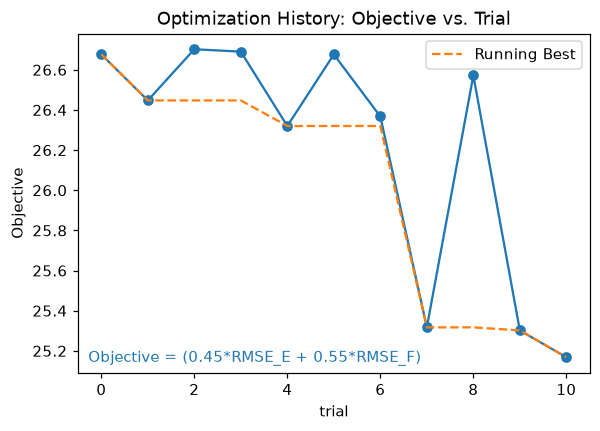

Objective: composite score (meV/atom + meV/Å, weighted)


In [5]:
# 1a. optimization history
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df["number"], df["value"], "o-")
running_best = df.sort_values("number")["value"].cummin()
ax.plot(df.sort_values("number")["number"], running_best, "--", label="Running Best")
ax.set_xlabel("trial")
ax.set_ylabel("Objective")
ax.set_title("Optimization History: Objective vs. Trial")
ax.text(0.02, 0.02, 
        "Objective = (0.45*RMSE_E + 0.55*RMSE_F)", 
        transform=ax.transAxes, ha="left", va="bottom",
        color="tab:blue")
ax.legend()
plt.show()

print("Objective: composite score (meV/atom + meV/Å, weighted)")

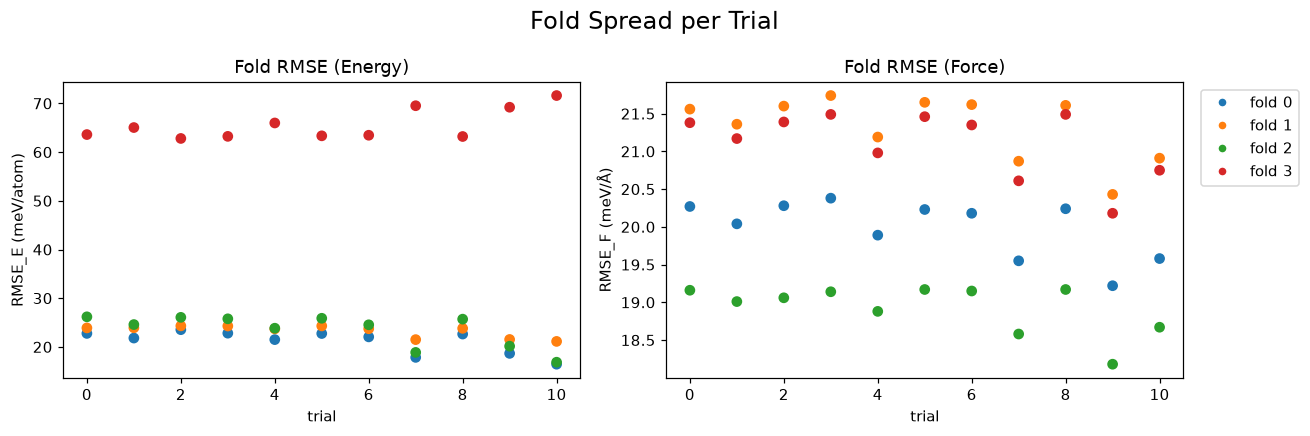

In [6]:
# 1c. fold spread per trial — the important one (fold-3 outlier check)
n_folds = len(df["fold_rmse_e"].iloc[0])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for metric_idx, (metric_name, ax) in enumerate(zip(["fold_rmse_e", "fold_rmse_f"], axes)):
    for _, row in df.sort_values("number").iterrows():
        vals = row[metric_name]
        xs = [row["number"]] * n_folds
        ax.scatter(xs, vals, c=range(n_folds), cmap="tab10", vmin=0, vmax=9)
    ax.set_xlabel("trial")
    y_name = "RMSE_E (meV/atom)" if metric_name == "fold_rmse_e" else "RMSE_F (meV/Å)"
    ax.set_ylabel(y_name)
    title_name = "Fold RMSE (Energy)" if metric_name == "fold_rmse_e" else "Fold RMSE (Force)"
    ax.set_title(title_name)

# legend for fold colors
handles = [plt.Line2D([0], [0], marker="o", color="w",
                       markerfacecolor=plt.cm.tab10(i / 9), label=f"fold {i}")
           for i in range(n_folds)]
axes[1].legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1))
fig.suptitle("Fold Spread per Trial", fontsize=16)
fig.tight_layout()
plt.show()

In [7]:
importances = optuna.importance.get_param_importances(study)
for param, imp in importances.items():
    print(f"{param:20s} {imp:.3f}")

swa_lr               0.652
swa_energy_weight    0.190
swa_forces_weight    0.085
lr                   0.048
weight_decay         0.024
